In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import re

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [2]:
columns = [
    "Sentiment",
    "ID",
    "Date",
    "Query",
    "User",
    "Text"
]

In [3]:
df = pd.read_csv(
    r"C:\Coding_Samurai\training.1600000.processed.noemoticon.csv\training.1600000.processed.noemoticon.csv",
    encoding="latin-1",
    names=columns
)

In [4]:
df = df[["Sentiment", "Text"]]

In [5]:
df = df.sample(n=10000, random_state=42)

In [6]:
df["Sentiment"] = df["Sentiment"].map({0: 0, 4: 1})

In [7]:
print("Sentiment Distribution")
print(df["Sentiment"].value_counts())

Sentiment Distribution
Sentiment
0    5004
1    4996
Name: count, dtype: int64


In [8]:
def clean_text(text):

    text = text.lower()

    text = re.sub(r"http\S+", "", text)

    text = re.sub(r"@\w+", "", text)

    text = re.sub(r"#", "", text)

    text = re.sub(r"[^a-zA-Z\s]", "", text)

    return text


df["Text"] = df["Text"].apply(clean_text)

In [9]:
vectorizer = CountVectorizer(stop_words="english")

X = vectorizer.fit_transform(df["Text"])

y = df["Sentiment"]

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [11]:

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [12]:
y_pred = model.predict(X_test)

In [15]:
print("\nAccuracy Score")
print(accuracy_score(y_test, y_pred))


Accuracy Score
0.703


In [16]:
print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))


Confusion Matrix
[[652 328]
 [266 754]]


In [17]:
print("\nClassification Report")
print(classification_report(y_test, y_pred))


Classification Report
              precision    recall  f1-score   support

           0       0.71      0.67      0.69       980
           1       0.70      0.74      0.72      1020

    accuracy                           0.70      2000
   macro avg       0.70      0.70      0.70      2000
weighted avg       0.70      0.70      0.70      2000



In [18]:
sample_text = ["I really enjoyed this movie."]

sample_text = [clean_text(text) for text in sample_text]

sample_vector = vectorizer.transform(sample_text)

prediction = model.predict(sample_vector)

if prediction[0] == 1:
    print("\nPredicted Sentiment : Positive")
else:
    print("\nPredicted Sentiment : Negative")



Predicted Sentiment : Positive


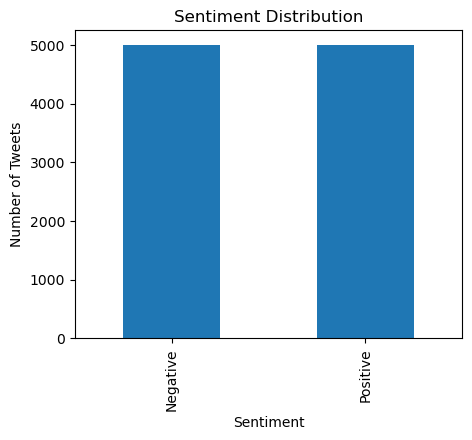

In [19]:
plt.figure(figsize=(5,4))

df["Sentiment"].value_counts().plot(kind="bar")

plt.xticks([0,1],["Negative","Positive"])

plt.title("Sentiment Distribution")

plt.xlabel("Sentiment")

plt.ylabel("Number of Tweets")

plt.show()
